In [1]:
########## Importing Libraries ##########
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
######## Loading the Dataset ##########
data = pd.read_csv("C:\\Users\\srush\\OneDrive\\Desktop\\AIML Internship\\AIML-Internship\\Day 14\\Student_Performance.csv.csv")
data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [25]:
### Exploratory Data Analysis (EDA) ###
# Displaying the first few rows of the dataset
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [26]:
### To check for data types and missing values ###
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [27]:
###  To get summary statistics ###
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [28]:
###  Check the number of rows and columns ###
data.shape

(10000, 6)

In [29]:
### To check the total number of elements in the dataset ###
data.size

60000

In [30]:
### Displaying the last few rows of the dataset
data.tail()        


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [31]:
#### Displaying the column names of the dataset
data.columns  

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='str')

In [32]:
#######  Data Cleaning ########
# Checking for missing values
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [33]:
#### Handling missing values (if any) - For example, filling with mean or dropping
#data.fillna(data.mean(), inplace=True)  # Uncomment if you want to fill missing values with mean
#data.dropna(inplace=True)  # Uncomment if you want to drop rows with missing values
    

In [36]:
### Checking for duplicates
data.duplicated().sum()


np.int64(127)

In [37]:
### Removing duplicates (if any)
data.drop_duplicates(inplace=True)


In [53]:
### checking the shape of the dataset after cleaning
data.shape

(9873, 5)

In [54]:
## Checking the datatype
data.dtypes

Hours Studied                         int64
Previous Scores                       int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [55]:
## Checking the Categorical columns
data.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [57]:
## Converting categorical columns to numeric using one-hot encoding
data = pd.get_dummies(data, drop_first=True)
data

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0
...,...,...,...,...,...
9995,1,49,4,2,23.0
9996,7,64,8,5,58.0
9997,6,83,8,5,74.0
9998,9,97,7,0,95.0


In [59]:
##### Data Distribution #####
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


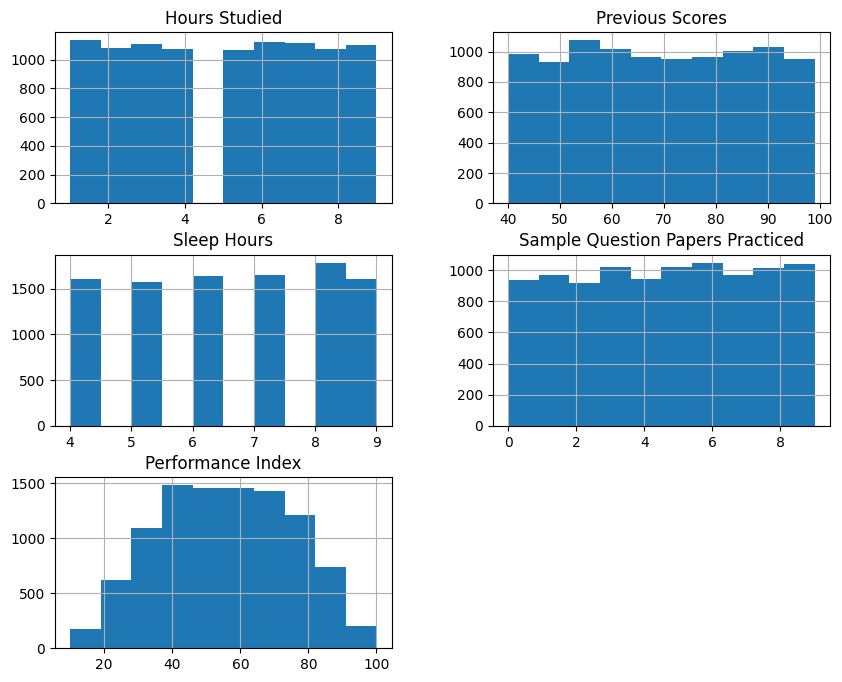

In [61]:
#### Histogram ####

data.hist(figsize=(10, 8))
plt.show()

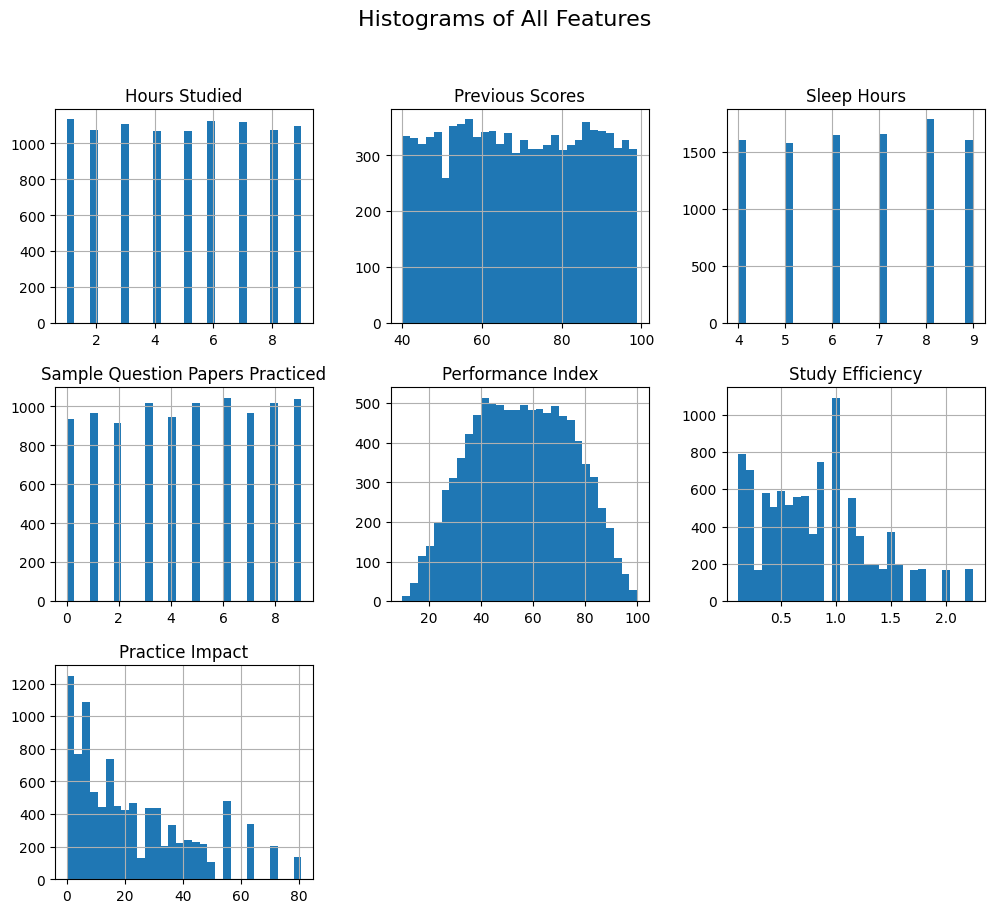

In [87]:
data.hist(bins=30, figsize=(12, 10))    
plt.suptitle('Histograms of All Features', fontsize=16)
plt.show()

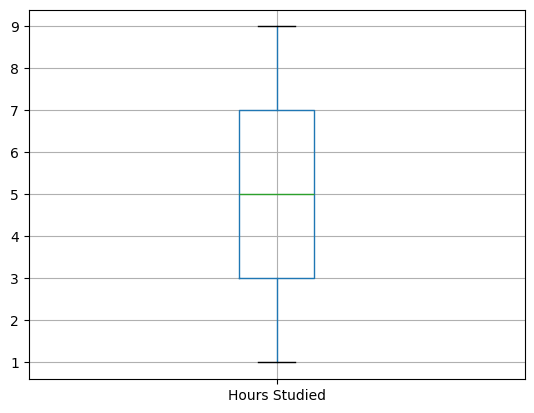

In [ ]:
### Boxplot (Outliers Detection) ###
data.boxplot(column='Hours Studied')
plt.show()


In [92]:
## Checking for skewness in the data ##
data.skew()


Hours Studied                      -0.003348
Previous Scores                     0.005581
Sleep Hours                        -0.041350
Sample Question Papers Practiced   -0.034893
Performance Index                  -0.000412
Study Efficiency                    0.680607
Practice Impact                     0.920744
dtype: float64

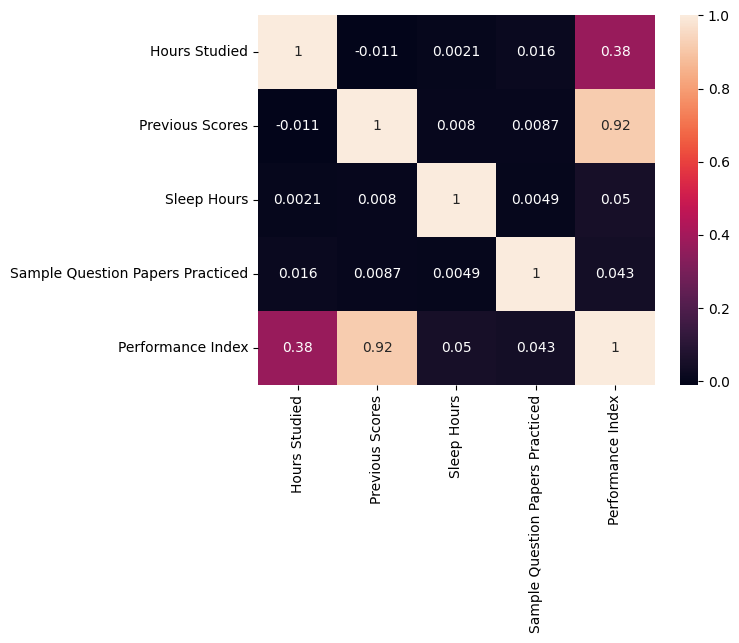

In [62]:
### Correlation Matrix ###
sns.heatmap(data.corr(), annot=True)
plt.show()


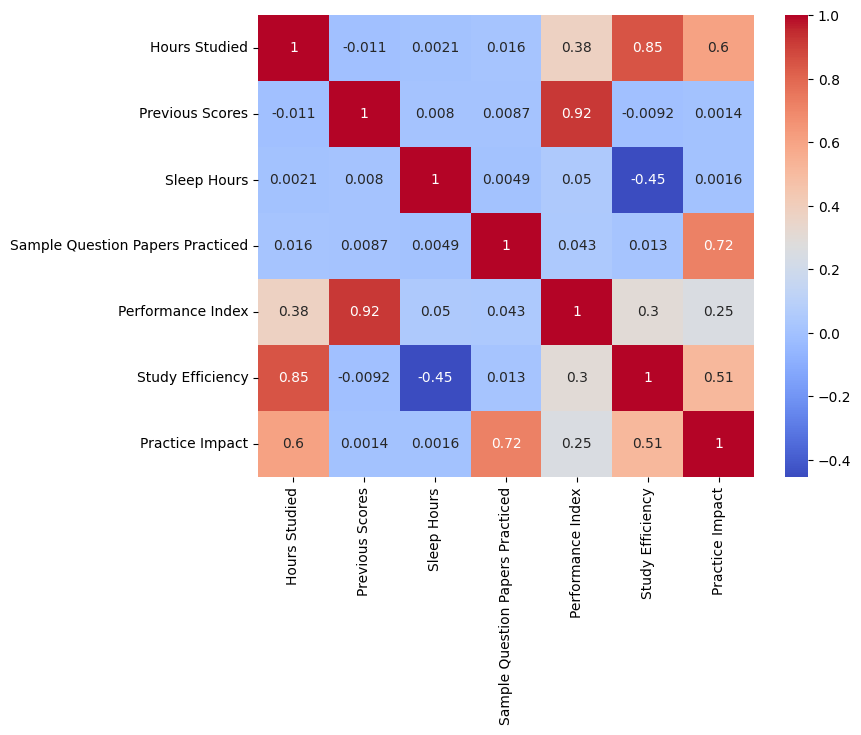

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
##### Data Transformation #####

### Feature Scaling ###

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = data.drop('Performance Index', axis=1)
y = data['Performance Index']

X_scaled = scaler.fit_transform(X)



In [86]:
scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

data_scaled.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Study Efficiency,Practice Impact
0,0.775566,1.706168,1.454025,-1.249715,1.862979,-0.091015,-0.794762
1,-0.383205,0.724912,-1.491315,-0.900925,0.509348,0.353423,-0.745076
2,1.161822,-1.064438,0.275889,-0.900925,-0.531907,0.639132,-0.347587
3,0.003052,-1.006717,-0.902247,-0.900925,-1.000471,0.353423,-0.645704
4,0.775566,0.320865,0.864957,0.145444,0.561411,0.103427,0.596451


In [75]:
### Feature Engineering ###

data['Study Efficiency'] = data['Hours Studied'] / data['Sleep Hours']
data


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Study Efficiency
0,7,99,9,1,91.0,0.777778
1,4,82,4,2,65.0,1.000000
2,8,51,7,2,45.0,1.142857
3,5,52,5,2,36.0,1.000000
4,7,75,8,5,66.0,0.875000
...,...,...,...,...,...,...
9995,1,49,4,2,23.0,0.250000
9996,7,64,8,5,58.0,0.875000
9997,6,83,8,5,74.0,0.750000
9998,9,97,7,0,95.0,1.285714


In [76]:
data['Practice Impact'] = data['Sample Question Papers Practiced'] * data['Hours Studied']
data

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Study Efficiency,Practice Impact
0,7,99,9,1,91.0,0.777778,7
1,4,82,4,2,65.0,1.000000,8
2,8,51,7,2,45.0,1.142857,16
3,5,52,5,2,36.0,1.000000,10
4,7,75,8,5,66.0,0.875000,35
...,...,...,...,...,...,...,...
9995,1,49,4,2,23.0,0.250000,2
9996,7,64,8,5,58.0,0.875000,35
9997,6,83,8,5,74.0,0.750000,30
9998,9,97,7,0,95.0,1.285714,0


In [78]:
## After adding new features
X = data.drop('Performance Index', axis=1)
y = data['Performance Index']
data


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Study Efficiency,Practice Impact
0,7,99,9,1,91.0,0.777778,7
1,4,82,4,2,65.0,1.000000,8
2,8,51,7,2,45.0,1.142857,16
3,5,52,5,2,36.0,1.000000,10
4,7,75,8,5,66.0,0.875000,35
...,...,...,...,...,...,...,...
9995,1,49,4,2,23.0,0.250000,2
9996,7,64,8,5,58.0,0.875000,35
9997,6,83,8,5,74.0,0.750000,30
9998,9,97,7,0,95.0,1.285714,0


In [ ]:
### Model Training ###

### Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression()

In [81]:
## Training the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
#### Model Evaluation ###

## Predicting on the test set
y_pred = model.predict(X_test)

In [83]:
### Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 4.449346797800404
R^2 Score: 0.9880446845278523


In [ ]:
## Calculating RMSE ##

import numpy as np


rmse = np.sqrt(4.449346797800404)  ### This value is the MSE calculated from the previous step
print(rmse)


2.109347481521336


In [90]:
### Comparing the Model Performance with and without Feature Engineering ###
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))


RF R2: 0.9841432570097968


In [ ]:
########## Polynomial Regression ##########
from sklearn.preprocessing import PolynomialFeatures

In [97]:
## Polynomial Features ##
poly = PolynomialFeatures(degree=2)
poly_features = poly.fit_transform(X_train)
model = LinearRegression()
model.fit(poly_features, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [98]:
## Training the Polynomial Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(poly_features, y_train)
model.coef_,model.intercept_

(array([ 0.00000000e+00,  7.38134392e+00,  1.76473382e+01,  7.94827817e-01,
         5.46184291e-01,  1.81541132e-02,  3.25957102e-03,  3.88335807e-02,
         2.16197801e-02, -2.19576829e-02,  1.88310880e-03, -1.96141326e-02,
         2.21284201e-02,  2.56209492e-02, -2.87648105e-03]),
 np.float64(55.189593481688995))

In [99]:
pred = model.predict(poly.fit_transform(X_test))
print("Polynomial Regression R2:", r2_score(y_test, pred))

Polynomial Regression R2: 0.9880500808086103


In [100]:
test_features = poly.fit_transform(X_test)

In [101]:
pred = model.predict(test_features)

In [102]:
### SVM (Support Vector Regression) ###
from sklearn.svm import SVR,SVC